In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv(r"C:\Users\Isaac\Desktop\文件管理\Homework\hw4.csv")

# 分离特征和标签
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 划分训练集和测试集（70%训练，30%测试，随机种子42）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")

训练集样本数: 274
测试集样本数: 118


测试集准确率: 0.7711864406779662
训练集准确率:  0.8029197080291971


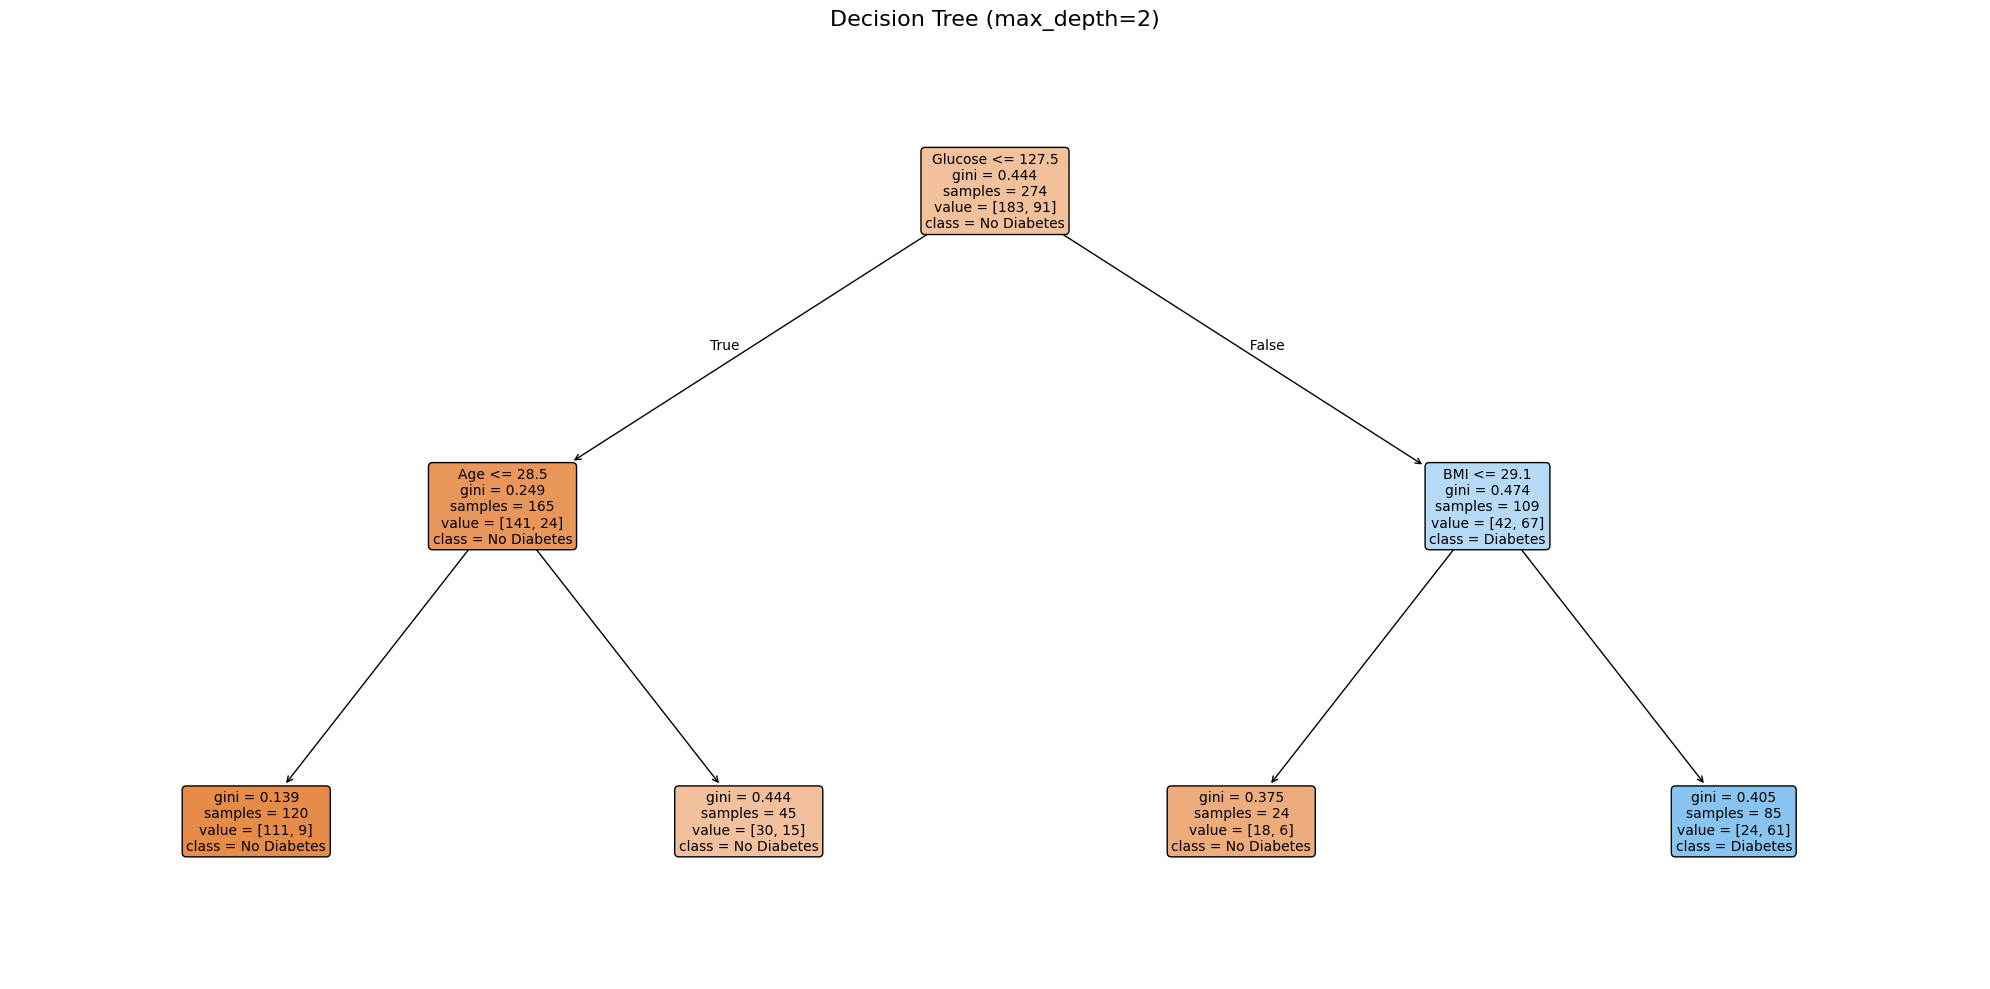

测试集准确率: 0.7796610169491526
训练集准确率:  0.8686131386861314


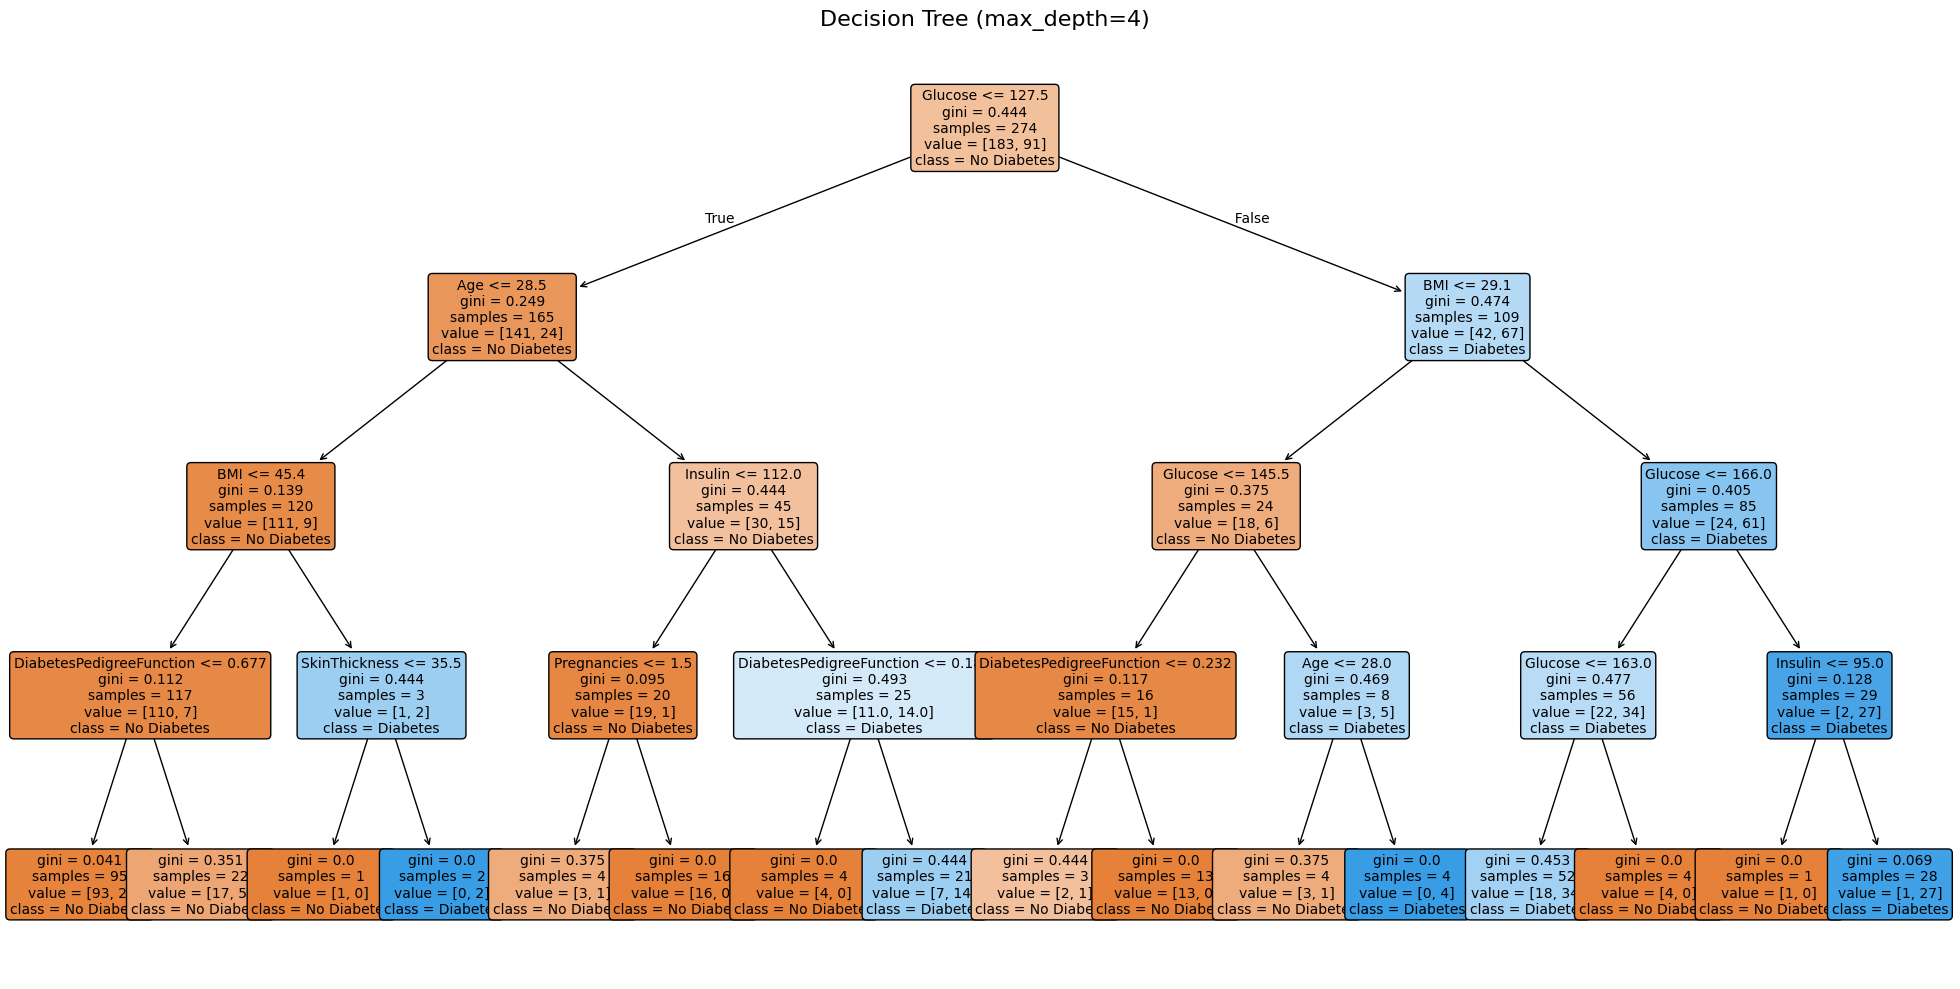

测试集准确率: 0.7457627118644068
训练集准确率:  0.9233576642335767


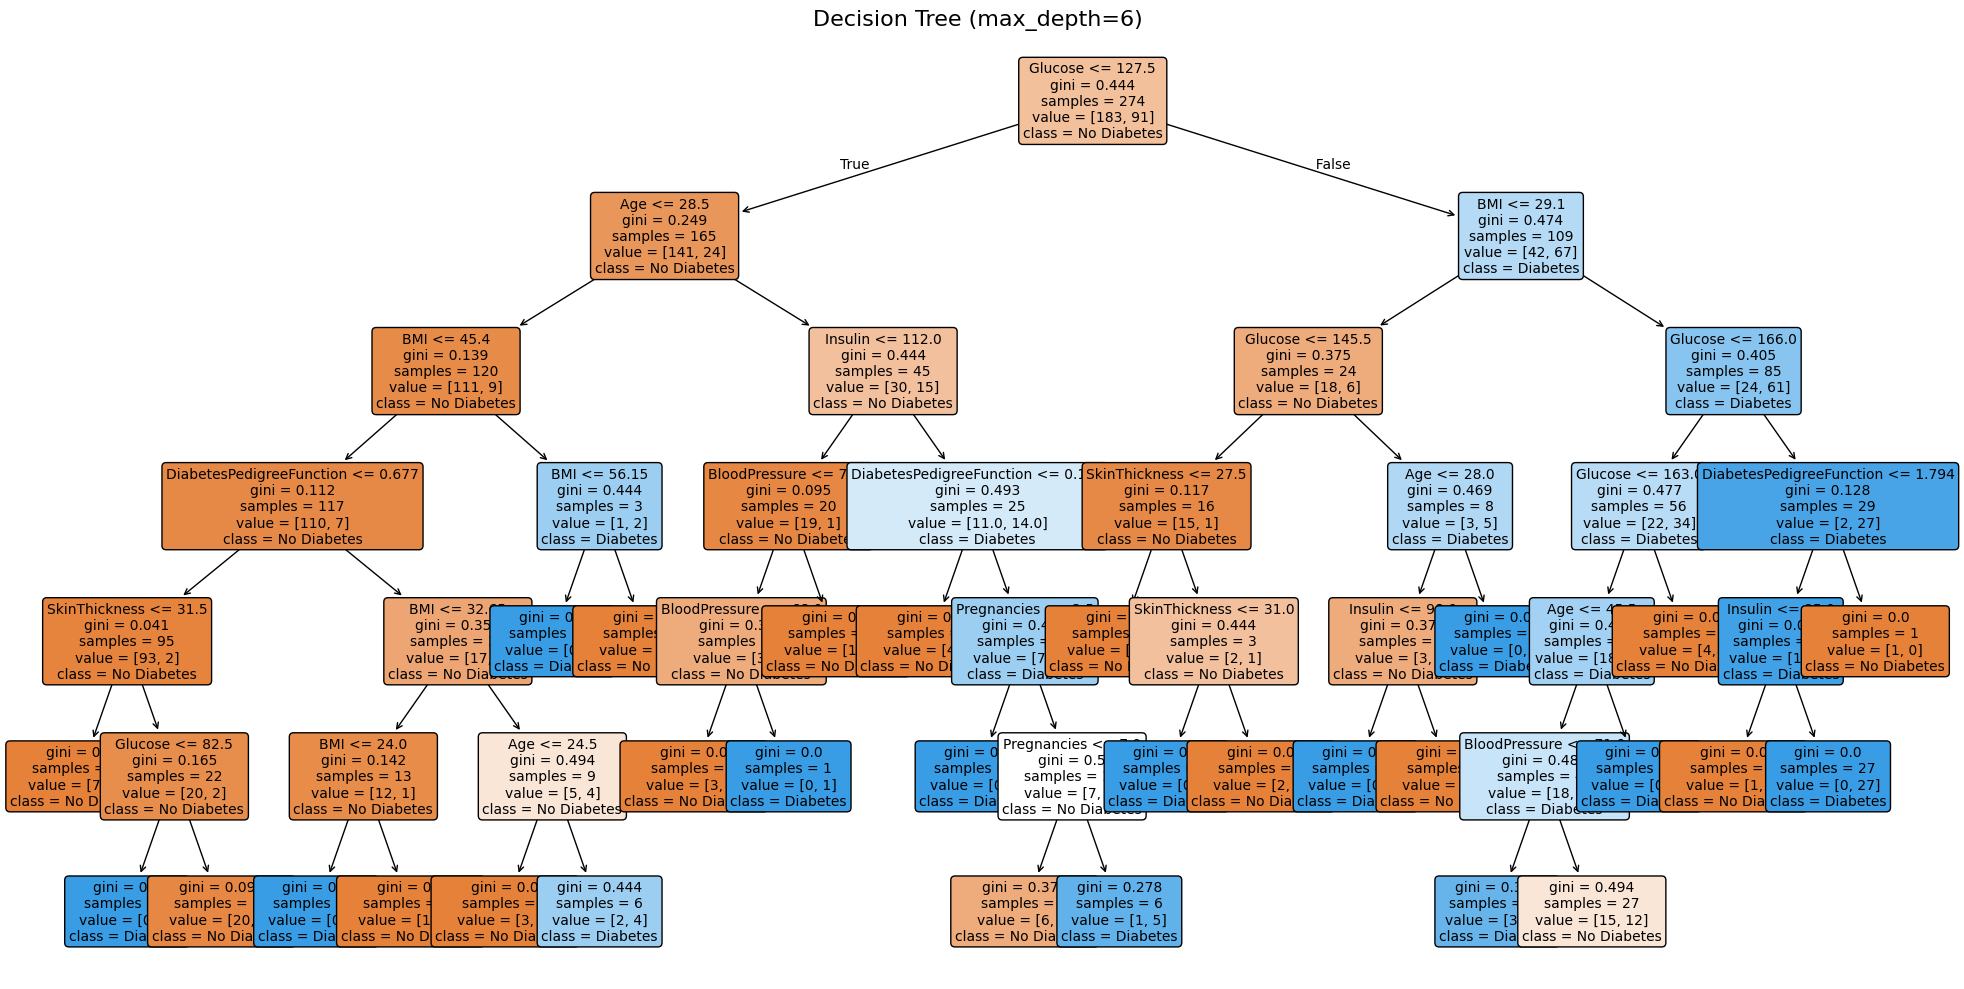

In [5]:
# (a) 对于不同的最大深度训练决策树
max_depths = [2, 4, 6]
for depth in max_depths:
    # 训练决策树分类器
    clf = DecisionTreeClassifier(max_depth=depth,random_state=42,criterion='gini')
    clf.fit(X_train, y_train)
    
    # 预测并计算准确率
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print("测试集准确率:" ,accuracy)
    print("训练集准确率: ",clf.score(X_train, y_train))
    
    # 绘制决策树
    plt.figure(figsize=(20, 10))
    plot_tree(
        clf,
        feature_names=X.columns,
        class_names=['No Diabetes', 'Diabetes'],
        filled=True,
        rounded=True,
        fontsize=10
    )
    plt.title(f'Decision Tree (max_depth={depth})', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'decision_tree_depth_{depth}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 如果是深度2的树，保存用于后续分析
    if depth == 2:
        clf_depth2 = clf

In [6]:
# (b) 分析深度为2的决策树的最重要特征

# 获取根节点使用的特征
root_feature = X.columns[clf_depth2.tree_.feature[0]]
print("\n根节点使用的特征:" ,root_feature)

# 获取第一层分裂使用的特征
second_level_features = []
left_child = clf_depth2.tree_.children_left[0]
right_child = clf_depth2.tree_.children_right[0]

if clf_depth2.tree_.feature[left_child] != -2:
    second_level_features.append(X.columns[clf_depth2.tree_.feature[left_child]])
if clf_depth2.tree_.feature[right_child] != -2:
    second_level_features.append(X.columns[clf_depth2.tree_.feature[right_child]])

print("第一层分裂使用的特征: ",second_level_features)

# 最重要的两个特征
important_features = [root_feature]
important_features.extend(second_level_features)
important_features = list(dict.fromkeys(important_features))  # 去重

print("\n最重要的两个特征是: ",important_features[:2])
print("\n原因: 这两个特征出现在决策树的根节点和第一层分裂节点，")
print("它们对数据的初始划分起到了最关键的作用，")
print("决定了大部分样本的分类路径，因此对预测结果影响最大。")


根节点使用的特征: Glucose
第一层分裂使用的特征:  ['Age', 'BMI']

最重要的两个特征是:  ['Glucose', 'Age']

原因: 这两个特征出现在决策树的根节点和第一层分裂节点，
它们对数据的初始划分起到了最关键的作用，
决定了大部分样本的分类路径，因此对预测结果影响最大。
